# 04 - Calibración de PCA

Antes de reducir dimensionalidad en forma permanente, evaluamos empíricamente qué umbral
de varianza PCA preserva la mayor parte de la información con la menor cantidad de dimensiones.

**Estrategia**: Usar un clasificador proxy rápido (LogisticRegression) sobre distintos
umbrales de varianza. LogReg converge en segundos y su ranking relativo de representaciones
es confiable — no necesitamos RF completo para tomar esta decisión.

**Entrada**: `data/embeddings/train_embeddings_raw.parquet`, `test_embeddings_raw.parquet`  
**Salida**: `results/pca_calibration.csv`, `results/pca_calibration.png`, decisión documentada en `decisions/pca_variance.md`

---

**Nota**: Este notebook detecta automáticamente qué archivos generó el notebook 03.
Si existe `train_embeddings_raw_subset.parquet` usa el subset (más rápido, ~10 min).
Si solo existe el completo, lo usa directamente (~2 horas).
El ranking de umbrales es estable entre ambos tamaños.

## 1. Importaciones

In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import time
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
print('✓ Librerías importadas')

✓ Librerías importadas


## 2. Carga de Embeddings Crudos

In [2]:
DATA_EMBEDDINGS = Path('../data/embeddings')
RESULTS_DIR     = Path('../results')
DECISIONS_DIR   = Path('../decisions')
RESULTS_DIR.mkdir(exist_ok=True)
DECISIONS_DIR.mkdir(exist_ok=True)

# Detectar automáticamente qué archivos generó el notebook 03
# Si existe el subset lo usa (más rápido); si no, usa el completo.
if (DATA_EMBEDDINGS / 'train_embeddings_raw_subset.parquet').exists():
    suffix = '_subset'
else:
    suffix = ''
print(f'Modo detectado: {"SUBSET" if suffix else "COMPLETO"}')

train_df = pd.read_parquet(DATA_EMBEDDINGS / f'train_embeddings_raw{suffix}.parquet')
test_df  = pd.read_parquet(DATA_EMBEDDINGS / f'test_embeddings_raw{suffix}.parquet')

emb_cols = [c for c in train_df.columns if c.startswith('emb_')]
X_train = train_df[emb_cols].values
X_test  = test_df[emb_cols].values
y_train = train_df['emotion'].values
y_test  = test_df['emotion'].values

print(f'Train : {X_train.shape}')
print(f'Test  : {X_test.shape}')
print(f'Clases: {np.unique(y_train)}')

Modo detectado: COMPLETO
Train : (436653, 384)
Test  : (109164, 384)
Clases: ['anger' 'fear' 'joy' 'love' 'sadness']


## 3. Búsqueda de Umbral Óptimo

Evaluamos umbrales de 50% a 100% (sin PCA) con LogisticRegression.
El objetivo es encontrar el punto donde agregar más varianza
deja de mejorar la performance de forma significativa.

In [3]:
THRESHOLDS = [0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.99]

results = []
print(f'{"Umbral":>8}  {"Dims":>5}  {"Accuracy":>9}  {"F1-Macro":>9}  {"Tiempo":>7}')
print('-' * 50)

for var in THRESHOLDS:
    t0 = time.time()
    pca = PCA(n_components=var, random_state=42)
    Xtr = pca.fit_transform(X_train)
    Xte = pca.transform(X_test)
    n_dims = Xtr.shape[1]

    clf = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
    clf.fit(Xtr, y_train)
    y_pred = clf.predict(Xte)

    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average='macro')
    elapsed = time.time() - t0

    results.append({'variance_threshold': var, 'n_dims': n_dims,
                    'accuracy': round(acc, 4), 'f1_macro': round(f1m, 4),
                    'time_s': round(elapsed, 1)})
    print(f'{var:>8.0%}  {n_dims:>5}  {acc:>9.4f}  {f1m:>9.4f}  {elapsed:>6.1f}s')

# Sin PCA
t0 = time.time()
clf = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1m = f1_score(y_test, y_pred, average='macro')
elapsed = time.time() - t0
results.append({'variance_threshold': 1.0, 'n_dims': X_train.shape[1],
                'accuracy': round(acc, 4), 'f1_macro': round(f1m, 4),
                'time_s': round(elapsed, 1)})
print(f'{1.0:>8.0%}  {X_train.shape[1]:>5}  {acc:>9.4f}  {f1m:>9.4f}  {elapsed:>6.1f}s  ← sin PCA')

  Umbral   Dims   Accuracy   F1-Macro   Tiempo
--------------------------------------------------
     50%     41     0.5389     0.3573    16.2s
     60%     62     0.5441     0.3662    16.6s
     70%     91     0.5492     0.3741    20.5s
     75%    110     0.5516     0.3787    23.9s
     80%    131     0.5548     0.3842    30.1s
     85%    156     0.5558     0.3874    37.7s
     90%    188     0.5582     0.3936    43.6s
     95%    232     0.5596     0.3974    58.6s
     99%    305     0.5641     0.4050   103.9s
    100%    384     0.5656     0.4080   203.1s  ← sin PCA


## 4. Análisis y Decisión

In [4]:
df = pd.DataFrame(results)

max_acc = df['accuracy'].max()

# Criterio: máxima ganancia marginal por dimensión añadida
# Para cada salto entre umbrales consecutivos (excluyendo sin-PCA),
# calculamos Δacc / Δdims. Elegimos el último umbral antes de que
# esa eficiencia caiga por debajo del 10% de la mejor eficiencia observada.
pca_df = df[df['variance_threshold'] < 1.0].reset_index(drop=True)
efficiencies = []
for i in range(1, len(pca_df)):
    delta_acc  = pca_df.iloc[i]['accuracy'] - pca_df.iloc[i-1]['accuracy']
    delta_dims = int(pca_df.iloc[i]['n_dims']) - int(pca_df.iloc[i-1]['n_dims'])
    efficiencies.append(delta_acc / delta_dims if delta_dims > 0 else 0)

best_eff = max(efficiencies)
threshold_eff = 0.10 * best_eff  # por debajo del 10% de la mejor → no vale la pena

# El codo es el último umbral ANTES de que la eficiencia caiga definitivamente
codo_idx = 0
for i, eff in enumerate(efficiencies):
    if eff >= threshold_eff:
        codo_idx = i  # índice en pca_df del umbral de LLEGADA de ese salto
codo = pca_df.iloc[codo_idx]

print('=' * 55)
print('ANÁLISIS')
print('=' * 55)
print(f'Accuracy máximo (sin PCA): {max_acc:.4f}')
print()
print(f'Ganancia marginal por umbral (Δacc / Δdims):')
for i, eff in enumerate(efficiencies):
    delta_acc  = pca_df.iloc[i+1]['accuracy'] - pca_df.iloc[i]['accuracy']
    delta_dims = int(pca_df.iloc[i+1]['n_dims']) - int(pca_df.iloc[i]['n_dims'])
    marker = ' ← codo' if i == codo_idx else ''
    print(f"  {pca_df.iloc[i]['variance_threshold']:.0%}→{pca_df.iloc[i+1]['variance_threshold']:.0%}"
          f"  +{delta_dims} dims  Δacc={delta_acc:+.4f}  eficiencia={eff:.6f}{marker}")
print()
print(f'Punto de codo (máx. eficiencia marginal):')
print(f'  Umbral : {codo.variance_threshold:.0%}')
print(f'  Dims   : {int(codo.n_dims)}')
print(f'  Accuracy: {codo.accuracy:.4f} ({codo.accuracy/max_acc*100:.1f}% del máximo)')

df.to_csv(RESULTS_DIR / 'pca_calibration.csv', index=False)
print()
print('✓ Guardado: results/pca_calibration.csv')

ANÁLISIS
Accuracy máximo (sin PCA): 0.5656

Ganancia marginal por umbral (Δacc / Δdims):
  50%→60%  +21 dims  Δacc=+0.0052  eficiencia=0.000248
  60%→70%  +29 dims  Δacc=+0.0051  eficiencia=0.000176
  70%→75%  +19 dims  Δacc=+0.0024  eficiencia=0.000126
  75%→80%  +21 dims  Δacc=+0.0032  eficiencia=0.000152
  80%→85%  +25 dims  Δacc=+0.0010  eficiencia=0.000040
  85%→90%  +32 dims  Δacc=+0.0024  eficiencia=0.000075
  90%→95%  +44 dims  Δacc=+0.0014  eficiencia=0.000032
  95%→99%  +73 dims  Δacc=+0.0045  eficiencia=0.000062 ← codo

Punto de codo (máx. eficiencia marginal):
  Umbral : 95%
  Dims   : 232
  Accuracy: 0.5596 (98.9% del máximo)

✓ Guardado: results/pca_calibration.csv


## 5. Visualización

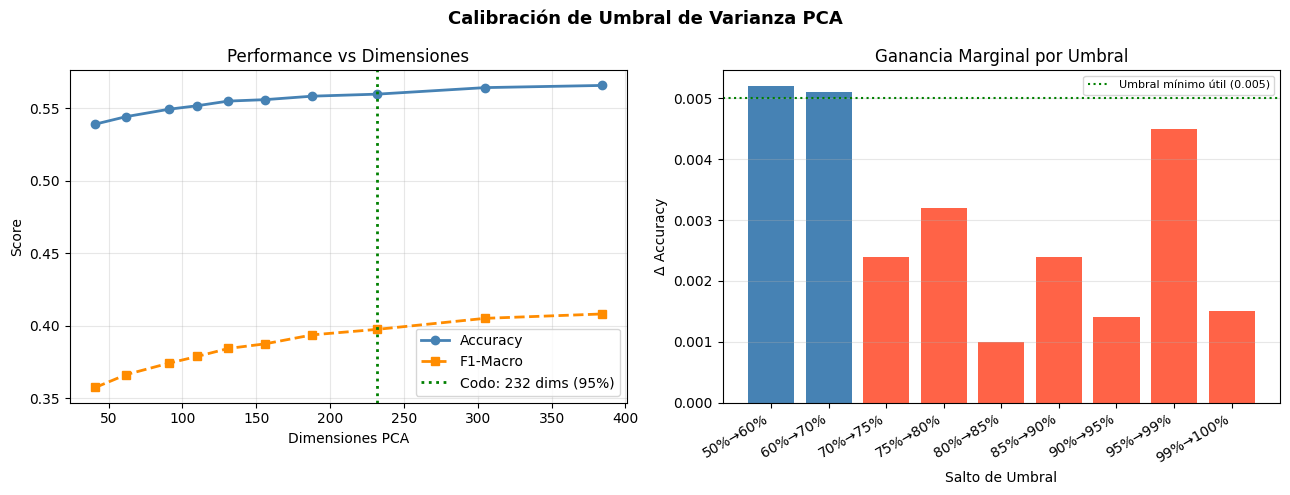

✓ Guardado: results/pca_calibration.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Calibración de Umbral de Varianza PCA', fontsize=13, fontweight='bold')

# Panel 1: accuracy vs dims
ax = axes[0]
ax.plot(df['n_dims'], df['accuracy'], 'o-', color='steelblue', linewidth=2, label='Accuracy')
ax.plot(df['n_dims'], df['f1_macro'], 's--', color='darkorange', linewidth=2, label='F1-Macro')
ax.axvline(int(codo.n_dims), color='green', linestyle=':', linewidth=2,
           label=f'Codo: {int(codo.n_dims)} dims ({codo.variance_threshold:.0%})')
ax.set_xlabel('Dimensiones PCA')
ax.set_ylabel('Score')
ax.set_title('Performance vs Dimensiones')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 2: ganancia marginal
ax = axes[1]
deltas = [df.iloc[i]['accuracy'] - df.iloc[i-1]['accuracy'] for i in range(1, len(df))]
labels = [f"{df.iloc[i-1]['variance_threshold']:.0%}→{df.iloc[i]['variance_threshold']:.0%}"
          for i in range(1, len(df))]
colors = ['tomato' if d < 0.005 else 'steelblue' for d in deltas]
ax.bar(labels, deltas, color=colors)
ax.axhline(0.005, color='green', linestyle=':', linewidth=1.5, label='Umbral mínimo útil (0.005)')
ax.set_xlabel('Salto de Umbral')
ax.set_ylabel('Δ Accuracy')
ax.set_title('Ganancia Marginal por Umbral')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()


## 6. Documentar Decisión

In [6]:
chosen_var  = float(codo.variance_threshold)
chosen_dims = int(codo.n_dims)
acc_chosen  = float(codo.accuracy)
acc_no_pca  = float(df[df['variance_threshold'] == 1.0]['accuracy'].values[0])
acc_loss    = acc_no_pca - acc_chosen

# Tamaño real del conjunto usado (puede ser subset o completo)
n_train = X_train.shape[0]
n_test  = X_test.shape[0]

dims_orig = X_train.shape[1]  # 384 para all-MiniLM-L6-v2

doc = (
    '# Decisión: Umbral de Varianza PCA\n\n'
    f'**Umbral elegido**: {chosen_var:.0%}  \n'
    f'**Dimensiones resultantes**: {chosen_dims} (de {dims_orig} originales)  \n'
    f'**Reducción**: {dims_orig - chosen_dims} dims eliminadas ({(dims_orig - chosen_dims)/dims_orig*100:.0f}%)  \n'
    '\n'
    '## Metodología\n\n'
    'Se evaluaron umbrales de 50% a 100% (sin PCA) usando LogisticRegression como clasificador\n'
    f'proxy sobre los embeddings disponibles ({n_train:,} train, {n_test:,} test).\n'
    'LogReg permite comparar representaciones en segundos con un ranking relativo confiable.\n'
    '\n'
    '## Resultados\n\n'
    '| Umbral | Dims | Accuracy | F1-Macro |\n'
    '|--------|------|----------|----------|\n'
)
for _, row in df.iterrows():
    marker = ' ← elegido' if row['variance_threshold'] == chosen_var else ''
    doc += f"| {row['variance_threshold']:.0%} | {int(row['n_dims'])} | {row['accuracy']:.4f} | {row['f1_macro']:.4f} |{marker}\n"

doc += (
    '\n## Criterio de Selección\n\n'
    'Se eligió el umbral con **máxima eficiencia marginal**: el último punto donde\n'
    'la ganancia de accuracy por dimensión añadida (Δacc/Δdims) sigue siendo relevante\n'
    '(≥10% de la mejor eficiencia observada en la curva).\n\n'
    'Este criterio evita el sesgo del método "99% del máximo", que en curvas sin codo\n'
    'abrupto tiende a elegir umbrales altos pagando muchas dimensiones por ganancias mínimas.\n\n'
    f'- **Accuracy sin PCA**: {acc_no_pca:.4f}\n'
    f'- **Accuracy con {chosen_var:.0%}**: {acc_chosen:.4f} ({acc_chosen/acc_no_pca*100:.1f}% del máximo)\n'
    f'- **Pérdida aceptada**: {acc_loss:.4f} ({acc_loss*100:.2f}%)\n'
    '\n## Referencias\n\n'
    '- Notebook: `notebooks/04_calibracion_pca.ipynb`  \n'
    '- Datos: `results/pca_calibration.csv`  \n'
    '- Gráfico: `results/pca_calibration.png`\n'
)

out = DECISIONS_DIR / 'pca_variance.md'
out.write_text(doc, encoding='utf-8')
print(f'✓ Decisión documentada: {out}')
print()
print(f'→ Usar PCA(n_components={chosen_var}) en notebook 05')
print(f'→ Dims resultantes: {chosen_dims}')


✓ Decisión documentada: ..\decisions\pca_variance.md

→ Usar PCA(n_components=0.95) en notebook 05
→ Dims resultantes: 232
